# 📊 Hábitos, estilo de vida e procrastinação

**Estudante:** Marllus Coutinho Nascimento Júnior  
**Matrícula:** 202505642

## 🎯 Objetivo
Investigar como **hábitos cotidianos**, **características das tarefas** e **fatores demográficos** estão associados ao nível de procrastinação dos participantes.

**Fonte:** [Procrastination Habits and Behaviors Data - Kaggle](https://www.kaggle.com/datasets/manaswinsripatnala/procrastination-habits-and-behaviors-data)

> O conjunto contém dados sintéticos. Portanto, os resultados representam padrões do dataset e não devem ser generalizados para toda a população.

## ❓ Perguntas de pesquisa

1. **Hábitos digitais:** o tempo de tela e o uso de redes sociais estão associados à procrastinação?
2. **Rotina pessoal:** o sono e a atividade física estão associados à procrastinação?
3. **Características das tarefas:** quais fatores apresentam maior relação com a procrastinação?
4. **Perfil dos participantes:** existem diferenças entre grupos demográficos?

## 1. 🧰 Bibliotecas e configurações

In [ ]:
from pathlib import Path
import csv
import warnings

warnings.filterwarnings('ignore', message='IProgress not found')
import kagglehub

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

## 2. 📥 Carregamento e visão geral dos dados

In [ ]:
# Download da versão mais recente do dataset diretamente do Kaggle
path = kagglehub.dataset_download(
    'manaswinsripatnala/procrastination-habits-and-behaviors-data'
)
print('Path to dataset files:', path)

pasta_dataset = Path(path)
arquivo = next(pasta_dataset.rglob('procrastination_survey_dataset.csv'))

with arquivo.open(encoding='utf-8', newline='') as arquivo_csv:
    linhas = list(csv.reader(arquivo_csv))

cabecalho_original = linhas[0]
posicao_ferramenta = cabecalho_original.index('scheduling_method') + 1
cabecalho = (cabecalho_original[:posicao_ferramenta]
             + ['scheduling_tool']
             + cabecalho_original[posicao_ferramenta:])

linhas_ajustadas = []
for linha in linhas[1:]:
    if not linha:
        continue
    if len(linha) == len(cabecalho_original):
        linha.insert(posicao_ferramenta, 'Not informed')
    if len(linha) != len(cabecalho):
        raise ValueError(f'Linha com {len(linha)} campos; esperado: {len(cabecalho)}')
    linhas_ajustadas.append(linha)

dados = pd.DataFrame(linhas_ajustadas, columns=cabecalho)

colunas_numericas = [
    'synthetic_flag', 'age', 'average_sleep_hours', 'daily_screen_time_hours',
    'daily_social_media_hours', 'work_hours_per_day', 'study_hours_per_day',
    'commute_hours_per_day', 'task_importance', 'task_difficulty', 'task_interest',
    'task_anxiety', 'task_clarity', 'task_complexity',
    'task_duration_estimate_hours', 'deadline_days_remaining',
    *[f'P{i:02d}' for i in range(1, 11)],
    *[f'S{i:02d}' for i in range(1, 11)],
    'stress_rating', 'mood_rating', 'energy_rating', 'concentration_difficulty',
    'feeling_overwhelmed_frequency', 'work_life_balance', 'perceived_control',
    'procrastination_score', 'scheduling_score', 'task_anxiety_score',
    'workload_score', 'social_media_avoidance_score', 'wellbeing_score'
]
dados[colunas_numericas] = dados[colunas_numericas].apply(pd.to_numeric)

print(f'Dimensões originais: {dados.shape[0]} linhas e {dados.shape[1]} colunas')
display(dados.head())

Path to dataset files: /tmp/kagglehub-cache/datasets/manaswinsripatnala/procrastination-habits-and-behaviors-data/versions/1
Dimensões originais: 300 linhas e 69 colunas


,participant_id,data_source,synthetic_flag,age,age_group,gender,education_level,employment_status,occupation_category,average_sleep_hours,...,concentration_difficulty,feeling_overwhelmed_frequency,work_life_balance,perceived_control,procrastination_score,scheduling_score,task_anxiety_score,workload_score,social_media_avoidance_score,wellbeing_score
0,P0001,synthetic_ai,1,19,18-20,Male,Undergraduate,Student,Education,6.5,...,6,6,5,4,3.8,2.6,4.00,2.19,4.00,4.2
1,P0002,synthetic_ai,1,34,30-39,Female,Postgraduate,Full-time employed,Healthcare,7.0,...,4,6,5,5,2.8,3.6,3.67,3.28,2.33,5.5
2,P0003,synthetic_ai,1,22,21-24,Female,Undergraduate,Student,Education,6.0,...,7,7,4,3,4.2,2.1,3.33,1.88,4.67,3.6
3,P0004,synthetic_ai,1,45,40-49,Male,Undergraduate,Full-time employed,Technology,7.5,...,5,5,6,6,3.4,3.6,4.33,3.28,3.00,5.8
4,P0005,synthetic_ai,1,28,25-29,Non-binary,Postgraduate,Full-time employed,Research,6.5,...,5,5,6,5,3.0,3.0,3.67,2.94,3.00,5.4


In [ ]:
resumo_inicial = pd.DataFrame({
    'tipo': dados.dtypes.astype(str),
    'valores_ausentes': dados.isna().sum(),
    'valores_unicos': dados.nunique()
})

print(f'Total de valores ausentes: {dados.isna().sum().sum()}')
display(resumo_inicial.head(15))

Total de valores ausentes: 0


,tipo,valores_ausentes,valores_unicos
participant_id,str,0,300
data_source,str,0,1
synthetic_flag,int64,0,1
age,int64,0,55
age_group,str,0,7
gender,str,0,3
education_level,str,0,6
employment_status,str,0,8
occupation_category,str,0,13
average_sleep_hours,float64,0,7


## 3. 🧹 Seleção e preparação das variáveis

Foram selecionados três grupos de informações:

- **Perfil:** idade, gênero, escolaridade e situação de emprego.
- **Hábitos:** sono, tempo de tela, redes sociais e atividade física.
- **Tarefas e comportamento:** características das tarefas e questões `P01`–`P10` e `S01`–`S10`.

### Construção dos índices

- **Índice de procrastinação:** média aritmética das questões `P01` a `P10`.
- **Índice de autorregulação:** média aritmética das questões `S01` a `S10`.
- **Escala:** os dois índices variam de **1 a 5**. Valores maiores indicam, respectivamente, maior procrastinação e maior autorregulação.
- **Peso das questões:** todas as dez questões recebem o mesmo peso no cálculo.

O campo `scheduling_tool` foi incluído no carregamento para alinhar as colunas do CSV.

In [ ]:
colunas_contexto = [
    'age', 'age_group', 'gender', 'education_level', 'employment_status',
    'occupation_category', 'average_sleep_hours', 'sleep_quality',
    'daily_screen_time_hours', 'daily_social_media_hours',
    'physical_activity_frequency', 'work_hours_per_day',
    'study_hours_per_day', 'commute_hours_per_day', 'perceived_workload',
    'task_type', 'task_importance', 'task_difficulty', 'task_interest',
    'task_anxiety', 'task_clarity', 'task_complexity',
    'task_duration_estimate_hours', 'deadline_days_remaining'
]
colunas_p = [f'P{i:02d}' for i in range(1, 11)]
colunas_s = [f'S{i:02d}' for i in range(1, 11)]

df = dados[colunas_contexto + colunas_p + colunas_s].copy()

df['indice_procrastinacao'] = df[colunas_p].mean(axis=1)
df['indice_autorregulacao'] = df[colunas_s].mean(axis=1)

print(f'Dimensões após a seleção: {df.shape[0]} linhas e {df.shape[1]} colunas')
print(f'Valores ausentes após a seleção: {df.isna().sum().sum()}')
display(df[['indice_procrastinacao', 'indice_autorregulacao']].describe().round(2))

Dimensões após a seleção: 300 linhas e 46 colunas
Valores ausentes após a seleção: 0


,indice_procrastinacao,indice_autorregulacao
count,300.00,300.00
mean,2.89,3.21
std,0.89,0.78
min,1.20,1.40
25%,2.00,3.00
50%,3.00,3.50
75%,3.60,3.80
max,4.90,4.20


### 📈 Distribuição do índice de procrastinação

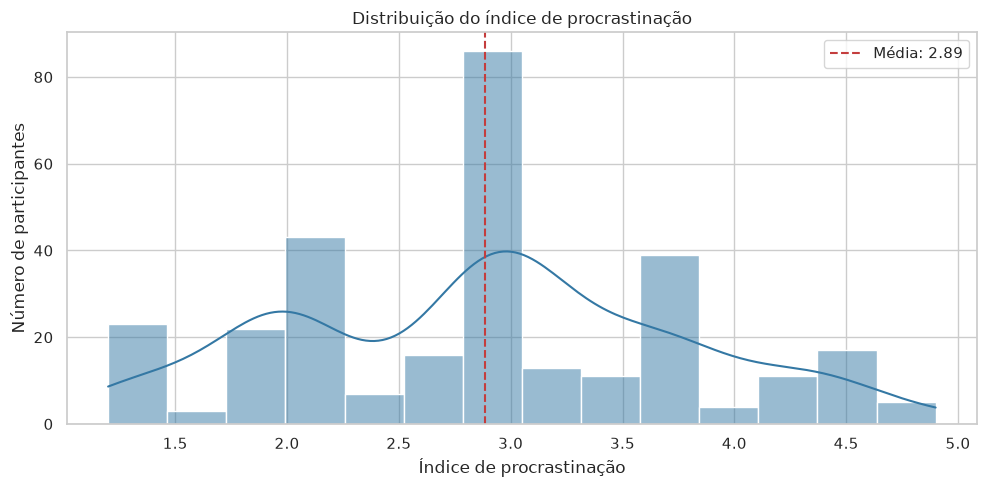

In [ ]:
media_indice = df['indice_procrastinacao'].mean()

plt.figure(figsize=(10, 5))
sns.histplot(df['indice_procrastinacao'], bins=14, kde=True, color='#3478A4')
plt.axvline(media_indice, color='#C43D3D', linestyle='--', label=f'Média: {media_indice:.2f}')
plt.title('Distribuição do índice de procrastinação')
plt.xlabel('Índice de procrastinação')
plt.ylabel('Número de participantes')
plt.legend()
plt.tight_layout()
plt.show()

## 4. 📱 Pergunta 1: tempo de tela e redes sociais

**Hipótese:** mais tempo de tela e de redes sociais está associado a um índice maior de procrastinação.

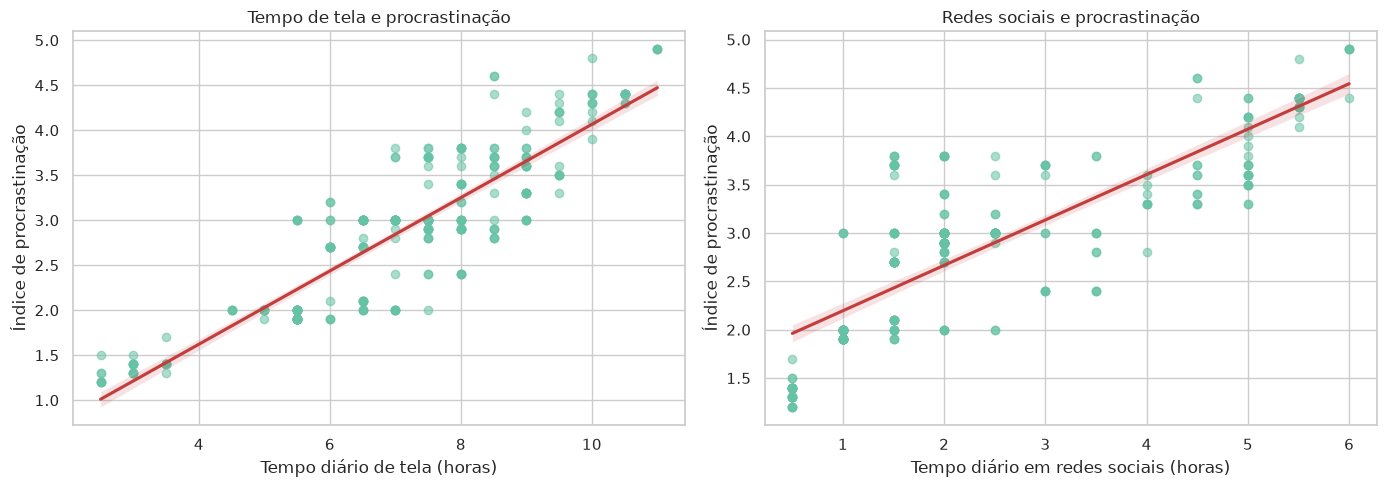

,correlação
daily_screen_time_hours,0.894
daily_social_media_hours,0.832


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=df, x='daily_screen_time_hours', y='indice_procrastinacao',
            scatter_kws={'alpha': 0.55}, line_kws={'color': '#C43D3D'}, ax=axes[0])
axes[0].set_title('Tempo de tela e procrastinação')
axes[0].set_xlabel('Tempo diário de tela (horas)')
axes[0].set_ylabel('Índice de procrastinação')

sns.regplot(data=df, x='daily_social_media_hours', y='indice_procrastinacao',
            scatter_kws={'alpha': 0.55}, line_kws={'color': '#C43D3D'}, ax=axes[1])
axes[1].set_title('Redes sociais e procrastinação')
axes[1].set_xlabel('Tempo diário em redes sociais (horas)')
axes[1].set_ylabel('Índice de procrastinação')

plt.tight_layout()
plt.show()

correlacoes_tela = df[[
    'daily_screen_time_hours', 'daily_social_media_hours', 'indice_procrastinacao'
]].corr()['indice_procrastinacao'].drop('indice_procrastinacao')
display(correlacoes_tela.to_frame('correlação').round(3))

### ✅ Resposta da pergunta 1

- **Tempo total de tela:** correlação de **0,894** com a procrastinação.
- **Tempo em redes sociais:** correlação de **0,832**.
- **Padrão observado:** mais horas de exposição às telas acompanham índices maiores.
- **Conclusão:** a hipótese foi confirmada, com associação mais forte para o tempo total de tela.

## 5. 🌙 Pergunta 2: sono e atividade física

**Hipótese:** melhor qualidade de sono e maior frequência de atividade física estão associadas a menor procrastinação.

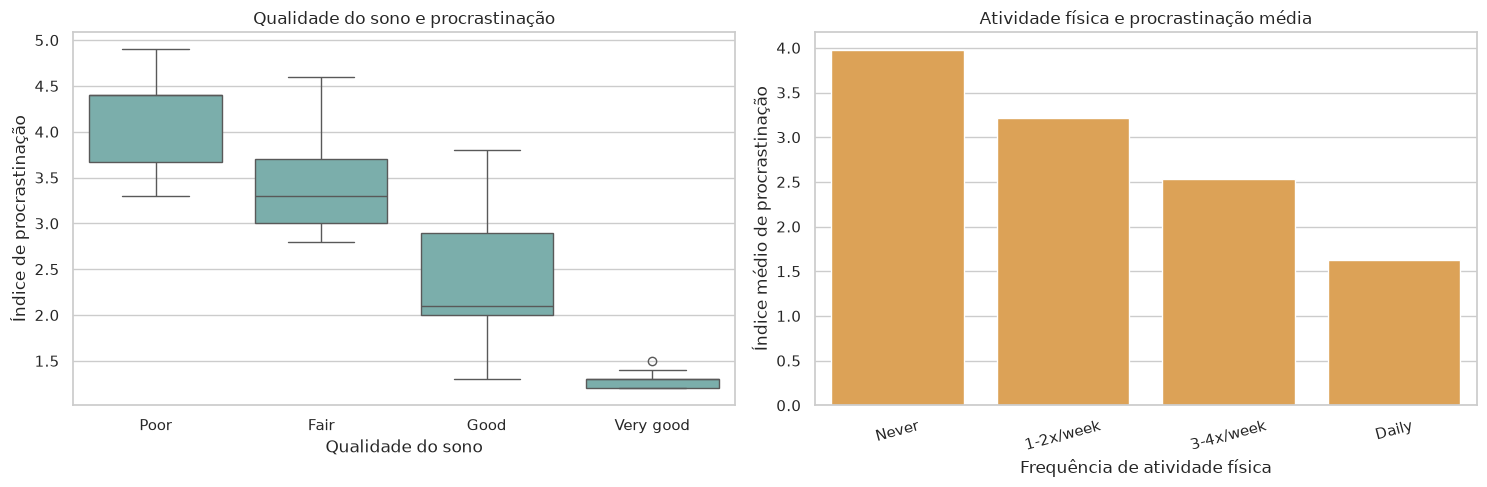

Média por qualidade do sono:


,mean,count
sleep_quality,,
Poor,4.15,36
Fair,3.41,94
Good,2.40,159
Very good,1.29,11


Média por frequência de atividade física:


,mean
physical_activity_frequency,
Never,3.97
1-2x/week,3.21
3-4x/week,2.54
Daily,1.63


In [ ]:
ordem_sono = ['Poor', 'Fair', 'Good', 'Very good']
ordem_atividade = ['Never', '1-2x/week', '3-4x/week', 'Daily']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=df, x='sleep_quality', y='indice_procrastinacao',
            order=ordem_sono, color='#72B7B2', ax=axes[0])
axes[0].set_title('Qualidade do sono e procrastinação')
axes[0].set_xlabel('Qualidade do sono')
axes[0].set_ylabel('Índice de procrastinação')

media_atividade = (df.groupby('physical_activity_frequency', observed=False)
                    ['indice_procrastinacao'].mean().reindex(ordem_atividade))
sns.barplot(x=media_atividade.index, y=media_atividade.values, color='#F2A541', ax=axes[1])
axes[1].set_title('Atividade física e procrastinação média')
axes[1].set_xlabel('Frequência de atividade física')
axes[1].set_ylabel('Índice médio de procrastinação')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

resumo_sono = (df.groupby('sleep_quality', observed=False)
               ['indice_procrastinacao'].agg(['mean', 'count'])
               .reindex(ordem_sono))
print('Média por qualidade do sono:')
display(resumo_sono.round(2))
print('Média por frequência de atividade física:')
display(media_atividade.to_frame('mean').round(2))

### ✅ Resposta da pergunta 2

- **Qualidade do sono:** a média caiu de **4,15** no sono ruim para **1,29** no sono muito bom.
- **Horas de sono:** correlação de **-0,860** com a procrastinação.
- **Atividade física:** a média caiu de **3,97** entre quem nunca pratica para **1,63** no grupo com prática diária.
- **Conclusão:** sono de melhor qualidade e atividade física frequente estão associados a menor procrastinação.

## 6. 🧩 Pergunta 3: características das tarefas

**Hipótese:** ansiedade, dificuldade e complexidade aumentam a procrastinação, enquanto clareza e interesse ajudam a reduzi-la.

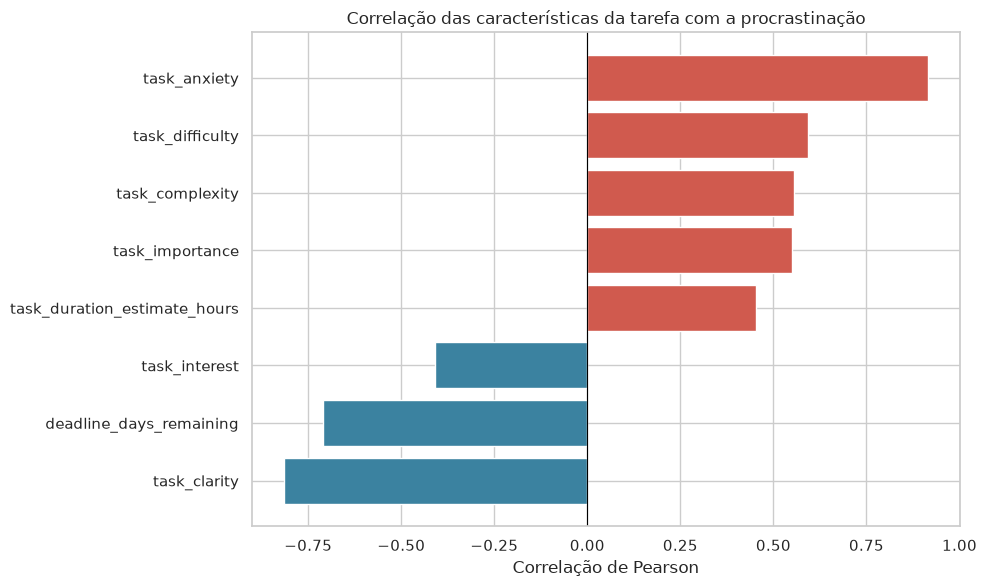

,correlação
task_clarity,-0.814
deadline_days_remaining,-0.712
task_interest,-0.408
task_duration_estimate_hours,0.453
task_importance,0.549
task_complexity,0.556
task_difficulty,0.592
task_anxiety,0.914


In [ ]:
variaveis_tarefa = [
    'task_importance', 'task_difficulty', 'task_interest', 'task_anxiety',
    'task_clarity', 'task_complexity', 'task_duration_estimate_hours',
    'deadline_days_remaining'
]

corr_tarefas = (df[variaveis_tarefa + ['indice_procrastinacao']]
                 .corr()['indice_procrastinacao']
                 .drop('indice_procrastinacao')
                 .sort_values())

cores = ['#3B82A0' if valor < 0 else '#D05A4E' for valor in corr_tarefas]
plt.figure(figsize=(10, 6))
plt.barh(corr_tarefas.index, corr_tarefas.values, color=cores)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlação das características da tarefa com a procrastinação')
plt.xlabel('Correlação de Pearson')
plt.ylabel('')
plt.tight_layout()
plt.show()

display(corr_tarefas.to_frame('correlação').round(3))

### ✅ Resposta da pergunta 3

- **Maior associação positiva:** ansiedade diante da tarefa (**0,914**).
- **Outros fatores positivos:** dificuldade (**0,592**) e complexidade (**0,556**).
- **Fatores negativos:** clareza (**-0,814**) e dias restantes até o prazo (**-0,712**).
- **Conclusão:** tarefas ansiosas, difíceis e complexas acompanham mais procrastinação; clareza e antecedência acompanham menos adiamento.

## 7. 👥 Pergunta 4: diferenças entre grupos demográficos

**Hipótese:** idade e situação de emprego estão associadas a diferentes níveis de procrastinação.

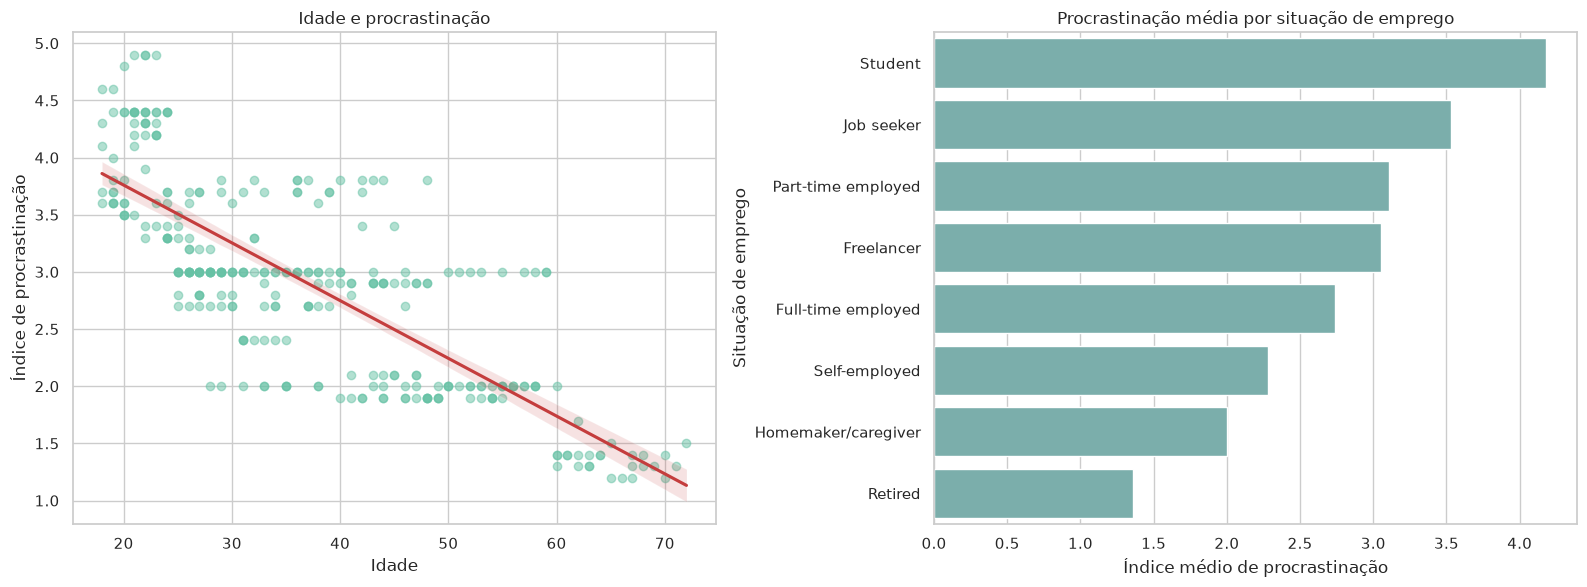

Correlação entre idade e procrastinação: -0.792


,mean,count
employment_status,,
Student,4.18,51
Job seeker,3.53,6
Part-time employed,3.11,10
Freelancer,3.05,11
Full-time employed,2.74,184
Self-employed,2.28,10
Homemaker/caregiver,2.00,2
Retired,1.36,26


In [ ]:
media_emprego = (df.groupby('employment_status', observed=False)
                 ['indice_procrastinacao'].agg(['mean', 'count'])
                 .sort_values('mean', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.regplot(data=df, x='age', y='indice_procrastinacao',
            scatter_kws={'alpha': 0.5}, line_kws={'color': '#C43D3D'}, ax=axes[0])
axes[0].set_title('Idade e procrastinação')
axes[0].set_xlabel('Idade')
axes[0].set_ylabel('Índice de procrastinação')

sns.barplot(data=media_emprego.reset_index(), x='mean', y='employment_status',
            color='#72B7B2', ax=axes[1])
axes[1].set_title('Procrastinação média por situação de emprego')
axes[1].set_xlabel('Índice médio de procrastinação')
axes[1].set_ylabel('Situação de emprego')

plt.tight_layout()
plt.show()

correlacao_idade = df['age'].corr(df['indice_procrastinacao'])
print(f'Correlação entre idade e procrastinação: {correlacao_idade:.3f}')
display(media_emprego.round(2))

### ✅ Resposta da pergunta 4

- **Idade:** correlação de **-0,792**, indicando redução do índice conforme a idade aumenta.
- **Estudantes:** maior média entre os grupos numerosos, com **4,18**.
- **Aposentados:** menor média, com **1,36**; empregados em período integral registraram **2,74**.
- **Cuidado na leitura:** grupos com poucos participantes não permitem comparações tão seguras.

## 8. 🔗 Análise combinada

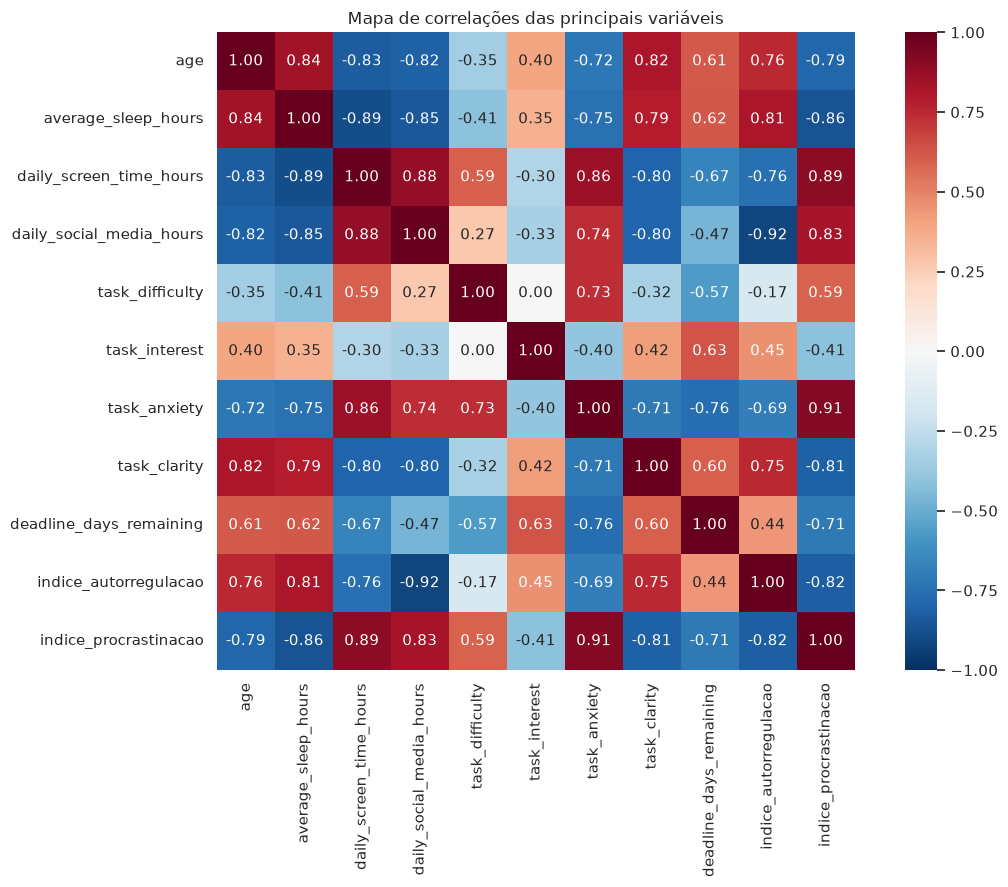

In [ ]:
variaveis_mapa = [
    'age', 'average_sleep_hours', 'daily_screen_time_hours',
    'daily_social_media_hours', 'task_difficulty', 'task_interest',
    'task_anxiety', 'task_clarity', 'deadline_days_remaining',
    'indice_autorregulacao', 'indice_procrastinacao'
]

plt.figure(figsize=(12, 9))
sns.heatmap(df[variaveis_mapa].corr(), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True)
plt.title('Mapa de correlações das principais variáveis')
plt.tight_layout()
plt.show()

## 9. 🎓 Conclusão final

A procrastinação aparece associada a uma combinação de fatores:

- **Hábitos digitais:** mais tempo de tela e de redes sociais acompanha índices maiores.
- **Rotina pessoal:** sono de qualidade e atividade física acompanham índices menores.
- **Características das tarefas:** ansiedade, dificuldade e complexidade aumentam a associação; clareza e antecedência reduzem.
- **Perfil dos participantes:** estudantes e pessoas mais jovens concentraram índices maiores neste dataset.
- **Autorregulação:** níveis mais altos aparecem ligados a menor procrastinação no mapa de correlações.

**Aplicação prática:** reduzir distrações digitais, organizar prazos, dividir tarefas complexas em etapas claras e cuidar do sono e da atividade física são estratégias coerentes com os padrões encontrados.

> Como o dataset é sintético, os resultados descrevem os padrões presentes nos dados analisados. As correlações mostram associação, mas não comprovam relações de causa e efeito nem devem ser generalizadas diretamente para toda a população.